In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [3]:
class state(TypedDict):

    a : int
    b : int 
    c : int 

    equation : str 
    discriminant : float
    result : str  


In [24]:
def equation(state:state):
    equ=f'{state['a']}^2 {state['b']}^x {state["c"]}'
    return {'equation':equ}

In [7]:
def discriminant(state:state):
   dis= state['b']**2 - (4*state['a']*state['c'])
   return {'discriminant':dis}

In [13]:
def real_root(state:state):
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    res=f'the two roots are {root1} and {root2}'
    return {'result':res}

In [14]:
def repeteted_root(state:state):
    root1 = (-state['b'])/ (2*state['a'])

    res=f'the repeteted roots are {root1} '
    return {'result':res}

In [15]:
def no_real_root(state:state):
    res=f'the is no root '
    return {'result':res}

In [16]:
def check_condition(state:state) -> Literal['real_root','repeteted_root','no_real_root']:
    if state['discriminant'] > 0:
        return 'real_root'
    elif state['discriminant'] == 0:
        return 'repeteted_root'
    else:
        return 'no_real_root'

In [25]:
graph=StateGraph(state)

graph.add_node("equation",equation)
graph.add_node("discriminant",discriminant)
graph.add_node('real_root',real_root)
graph.add_node('repeteted_root',repeteted_root)
graph.add_node('no_real_root',no_real_root)

graph.add_edge(START,"equation")
graph.add_edge("equation","discriminant")
graph.add_conditional_edges("discriminant",check_condition)
graph.add_edge("real_root",END)
graph.add_edge("repeteted_root",END)
graph.add_edge("no_real_root",END)


workflow=graph.compile()

intial_state={'a':4,'b':2,'c':4}
workflow.invoke(intial_state)



{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4^2 2^x 4',
 'discriminant': -60,
 'result': 'the is no root '}

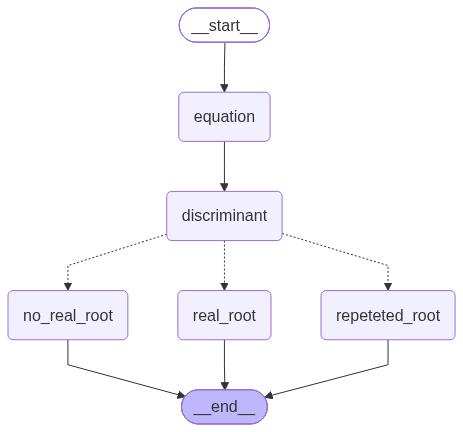

In [18]:
workflow